Net(
  (fc1): Linear(in_features=2, out_features=1, bias=False)
)
[Parameter containing:
tensor([[ 1., -1.]], requires_grad=True)]
Epoch 0 - loss: 39.33453241984049
Epoch 1 - loss: 80.62562874952953
Epoch 2 - loss: 37.82995556791624
Epoch 3 - loss: 75.12151177724202
Epoch 4 - loss: 37.67473294337591
Epoch 5 - loss: 74.59152475992839
Epoch 6 - loss: 37.39508213599523
Epoch 7 - loss: 74.14079674084981
Epoch 8 - loss: 37.11633280913035
Epoch 9 - loss: 73.69497859477997
Epoch 10 - loss: 36.84047613541285
Epoch 11 - loss: 73.25286400318146
Epoch 12 - loss: 36.567521711190544
Epoch 13 - loss: 72.81440683205922
Epoch 14 - loss: 36.29744573434194
Epoch 15 - loss: 72.37959468364716
Epoch 16 - loss: 36.030199348926544
Epoch 17 - loss: 71.94831438859303
Epoch 18 - loss: 35.765770614147186
Epoch 19 - loss: 71.52061120669048
Epoch 20 - loss: 35.50412412484487
Epoch 21 - loss: 71.09644563992818
Epoch 22 - loss: 35.24523860216141
Epoch 23 - loss: 70.67576118310292
Epoch 24 - loss: 34.98907579978307
E

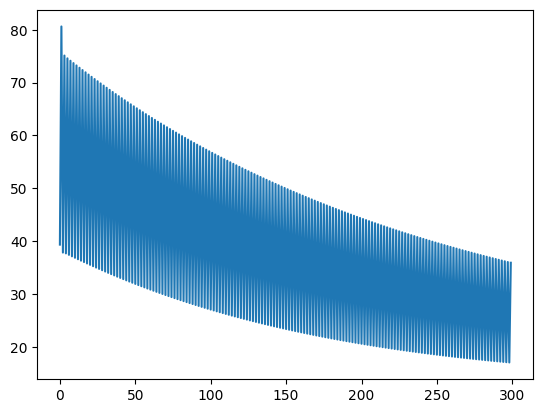

In [ ]:
import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
import matplotlib.pyplot as plt

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(2,1,bias=False)
    def forward(self, x):
        x = self.fc1(x)
        return x

net = Net()
print(net)


net.fc1.weight = torch.nn.Parameter(torch.tensor([[1., -1.]], requires_grad=True))

print(list(net.parameters()))

#input = torch.randn(1,2)
#out = net(input)


criterion = nn.MSELoss()
#def criterion(out, label):
#    return ((label - out)**2).mean()


optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.5)
#optimizer = optim.Adam(net.parameters(), lr=0.005)


data = torch.tensor([[1.,3.], [2.,6.], [3.,9.]], dtype=torch.float)
target = torch.tensor([[1.],[5.],[13.]], dtype=torch.float)

hist = []

############## SGD based update ##############
for epoch in range(300):
    epoch_loss = 0.
    for x, y in zip(data, target):          # iterate over individual samples
        optimizer.zero_grad()
        output = net(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    hist.append(epoch_loss / len(data))     # average loss over the epoch
    print("Epoch {} - loss: {}".format(epoch, epoch_loss / len(data)))
########################################################################

### Test the trained network ###
for i, current_data in enumerate(data):
    out = net(current_data)  
    print("when x = {}, y = {}".format(current_data, out))
    
plt.plot(hist, label = "training curve")